Shape: (2951, 76)
Number of unique input rows: 592
First columns: ['input_row_key', 'input_company_name', 'input_main_country_code', 'input_main_country', 'input_main_region', 'input_main_city', 'input_main_postcode', 'input_main_street', 'input_main_street_number', 'veridion_id', 'company_name', 'company_legal_names', 'company_commercial_names', 'main_country_code', 'main_country']

Global feature coverage:
name_score        1.000000
industry_score    0.974585
country_score     0.950864
city_score        0.778380
domain_score      0.775669
dtype: float64

Decision summary:
match        429
ambiguous    154
no_match       9
Name: decision, dtype: int64

=== TEST 1: decision counts ===
match        429
ambiguous    154
no_match       9
Name: decision, dtype: int64

=== TEST 2: top confident matches ===
     input_row_key                input_company_name best_company_name  \
415            415                    QUALTRICS, LLC         Qualtrics   
154            154                     

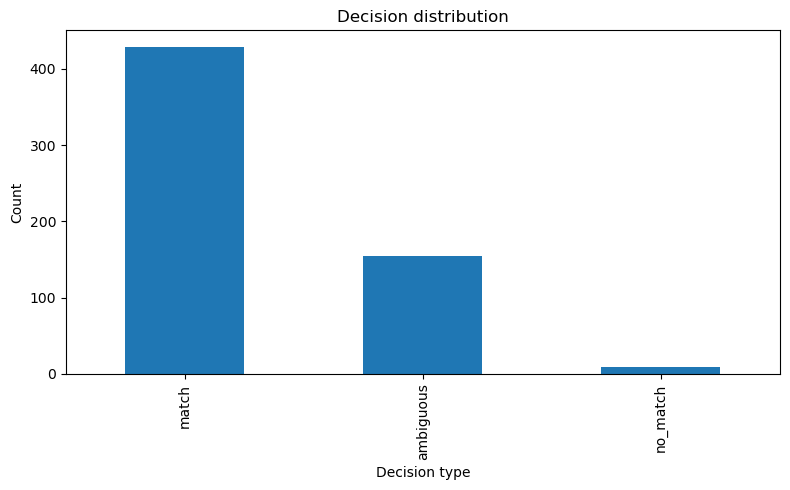

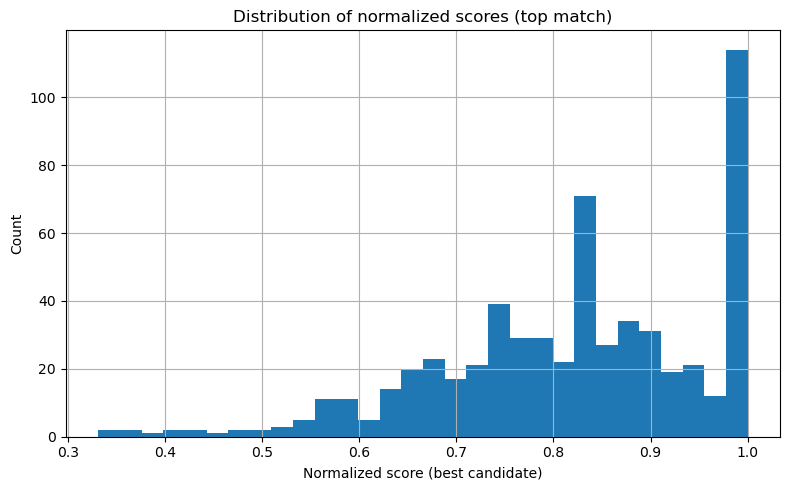

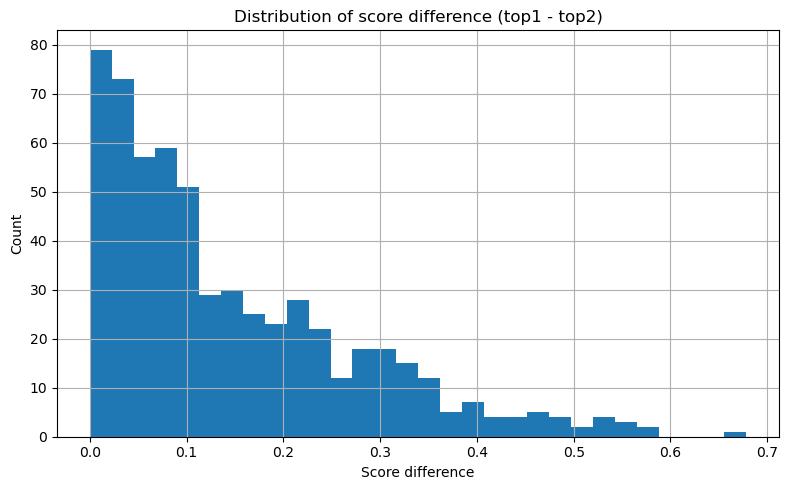


Saved files:
- entity_resolution_results_simple.csv


In [1]:
import pandas as pd
import numpy as np
import re
from difflib import SequenceMatcher
from urllib.parse import urlparse
import matplotlib.pyplot as plt


# =========================================================
# 1. Data loading
# =========================================================
df = pd.read_csv("presales_data_sample.csv")

print("Shape:", df.shape)
print("Number of unique input rows:", df["input_row_key"].nunique())
print("First columns:", df.columns.tolist()[:15])


# =========================================================
# 2. Data normalization and cleaning
# =========================================================
LEGAL_SUFFIXES = {
    "srl", "sa", "ltd", "limited", "gmbh", "llc", "inc", "corp",
    "corporation", "co", "company", "bv", "nv", "plc", "pte",
    "private", "public"
}

# Normalizes text:
# - if empty -> empty string
# - lowercase
# - replaces punctuation with spaces
# - compresses multiple spaces
    
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Cleans the company name and removes common legal suffixes
# e.g. "Delta Logistics SRL" becomes "delta logistics"

def normalize_company_name(name):
    text = clean_text(name)
    if not text:
        return ""

    tokens = [t for t in text.split() if t not in LEGAL_SUFFIXES]
    return " ".join(tokens)


# In the dataset, company_legal_names and company_commercial_names
# may contain multiple names separated by the | character
# Returns a list with the separated names

def split_multi_value_names(value):
    if pd.isna(value):
        return []

    raw = str(value)
    parts = [p.strip() for p in raw.split("|")]
    parts = [p for p in parts if p]
    return parts

# Simple similarity between two texts, returning values between 0 and 1
def similarity(a, b): 
    a = clean_text(a)
    b = clean_text(b)
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, a, b).ratio()

# Similarity between two company names
def company_name_similarity(a, b):

    a = normalize_company_name(a)
    b = normalize_company_name(b)
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, a, b).ratio()


# =========================================================
# 3. Functions for website and email domain
# =========================================================

# Lowercases and removes www. from the domain
def normalize_domain(domain):

    if pd.isna(domain):
        return ""
    domain = str(domain).strip().lower()
    domain = re.sub(r"^https?://", "", domain)
    domain = domain.split("/")[0]
    domain = domain.replace("www.", "")
    return domain

# Extracts the domain from the email, for example:
# contact@company.com -> company.com
def extract_domain_from_email(email):
    if pd.isna(email):
        return ""
    email = str(email).strip().lower()
    if "@" not in email:
        return ""
    return email.split("@")[-1]

# Useful tokens from the company name after normalization
# Very short tokens are removed
def company_name_tokens(name):
    norm = normalize_company_name(name)
    return [t for t in norm.split() if len(t) >= 3]


# =========================================================
# 4. Feature functions
# =========================================================

# Compares input_company_name with: company_name,
# company_legal_names, company_commercial_names
# Returns the maximum score across all variants
    
def feature_name_score(row):
    input_name = row.get("input_company_name", "")
    candidate_names = []

    candidate_names.append(row.get("company_name", ""))

    for val in split_multi_value_names(row.get("company_legal_names")):
        candidate_names.append(val)

    for val in split_multi_value_names(row.get("company_commercial_names")):
        candidate_names.append(val)

    scores = [company_name_similarity(input_name, cand) for cand in candidate_names if clean_text(cand)]
    return max(scores) if scores else 0.0

# Checks whether the country matches

def feature_country_score(row):
    a = clean_text(row.get("input_main_country_code"))
    b = clean_text(row.get("main_country_code"))

    if not a or not b:
        return np.nan
    return 1.0 if a == b else 0.0

# Checks whether the city matches, a less important factor than country

def feature_city_score(row):
    a = clean_text(row.get("input_main_city"))
    b = clean_text(row.get("main_city"))

    if not a or not b:
        return np.nan
    return 1.0 if a == b else 0.0

# Checks website_domain and primary_email
# Score:
# - 1.0 if website_domain seems to reflect the input company name
# - +1.0 if email domain = website domain

def feature_domain_score(row):

    input_name = row.get("input_company_name", "")
    website_domain = normalize_domain(row.get("website_domain"))
    email_domain = normalize_domain(extract_domain_from_email(row.get("primary_email")))

    if not website_domain and not email_domain:
        return np.nan

    score = 0.0

    tokens = company_name_tokens(input_name)
    if website_domain and tokens:
        matched_tokens = sum(1 for t in tokens if t in website_domain)
        if matched_tokens > 0:
            score += min(1.0, matched_tokens / max(1, len(tokens)))

    if website_domain and email_domain and website_domain == email_domain:
        score += 1.0

    return min(score, 1.0)

# Simple semantic signal based on:
# main_industry, main_sector, naics_2022_primary_label,
# short_description/generated_description
# Since the input does not have its own description,
# the input name is used instead
# this score has a small weight in the total
    
def feature_industry_score(row):
    input_name = normalize_company_name(row.get("input_company_name"))
    if not input_name:
        return np.nan

    candidate_text = " ".join([
        clean_text(row.get("main_industry")),
        clean_text(row.get("main_sector")),
        clean_text(row.get("naics_2022_primary_label")),
        clean_text(row.get("short_description")),
        clean_text(row.get("generated_description")),
    ]).strip()

    if not candidate_text:
        return np.nan

    tokens = [t for t in input_name.split() if len(t) >= 4]
    if not tokens:
        return 0.0

    overlap = sum(1 for t in tokens if t in candidate_text)
    return min(1.0, overlap / len(tokens))


# =========================================================
# 5. Dynamic weighting based on available data
# =========================================================

BASE_WEIGHTS = {
    "name_score": 4.0,
    "country_score": 2.5,
    "city_score": 1.5,
    "domain_score": 1.0,
    "industry_score": 0.5,
}

# Percentage of rows in the group for which the feature exists
# (there are cases where many values are null)

def feature_coverage(group, feature_col):
    
    return group[feature_col].notna().mean()

# If a feature is missing everywhere -> weight 0
# If it appears very rarely -> downweight
# If it is reasonably present -> use almost the full weight

def adjusted_weight(base_weight, coverage):

    if coverage == 0:
        return 0.0
    elif coverage < 0.4:
        return base_weight * 0.5
    elif coverage < 0.8:
        return base_weight * 0.8
    else:
        return base_weight


# =========================================================
# 6. Defining the initial features
# =========================================================

df["name_score"] = df.apply(feature_name_score, axis=1)
df["country_score"] = df.apply(feature_country_score, axis=1)
df["city_score"] = df.apply(feature_city_score, axis=1)
df["domain_score"] = df.apply(feature_domain_score, axis=1)
df["industry_score"] = df.apply(feature_industry_score, axis=1)

feature_cols = list(BASE_WEIGHTS.keys())
print("\nGlobal feature coverage:")
print(df[feature_cols].notna().mean().sort_values(ascending=False))


# =========================================================
# 7. Group-level scoring with dynamic weights
# =========================================================

# For each input_row_key:
# 1. compute feature coverage
# 2. adjust the weights
# 3. compute the final score for each candidate

def score_group(group):
    group = group.copy()

    # weights adjusted based on how much the feature is missing in the group
    group_weights = {}
    for feat, base_w in BASE_WEIGHTS.items():
        cov = feature_coverage(group, feat)
        group_weights[feat] = adjusted_weight(base_w, cov)

    # raw score
    def row_score(row):
        total = 0.0
        for feat, weight in group_weights.items():
            val = row.get(feat)
            if pd.notna(val):
                total += val * weight
        return total

    group["final_score"] = group.apply(row_score, axis=1)

    # optional: normalized score by the sum of active weights
    active_weight_sum = sum(group_weights.values())
    if active_weight_sum > 0:
        group["normalized_score"] = group["final_score"] / active_weight_sum
    else:
        group["normalized_score"] = 0.0

    # store the weights used for debugging
    for feat, weight in group_weights.items():
        group[f"weight_{feat}"] = weight

    return group

scored_df = df.groupby("input_row_key", group_keys=False).apply(score_group)


# =========================================================
# 8. Decision: BEST MATCH / NO_MATCH / AMBIGUOUS
# =========================================================

# We use normalized_score for the decision because groups may have
# different available features
# Rules:
# - choose the candidate with the highest score
# - if the score is too low -> no_match
# - if the top 2 are very close -> ambiguous

def decide_group(group, min_score_threshold=0.45, ambiguity_gap=0.05):

    group = group.sort_values("normalized_score", ascending=False).copy()

    best = group.iloc[0]
    second_score = group.iloc[1]["normalized_score"] if len(group) > 1 else 0.0
    gap = best["normalized_score"] - second_score

    if best["normalized_score"] < min_score_threshold:
        decision = "no_match"
    elif gap < ambiguity_gap:
        decision = "ambiguous"
    else:
        decision = "match"

    return pd.Series({
        "input_row_key": best["input_row_key"],
        "input_company_name": best["input_company_name"],
        "best_veridion_id": best["veridion_id"],
        "best_company_name": best["company_name"],
        "best_country": best["main_country"],
        "best_city": best["main_city"],
        "best_website_domain": best["website_domain"],
        "best_normalized_score": best["normalized_score"],
        "second_best_score": second_score,
        "score_gap": gap,
        "decision": decision
    })

results = scored_df.groupby("input_row_key").apply(decide_group).reset_index(drop=True)

print("\nDecision summary:")
print(results["decision"].value_counts(dropna=False))


# =========================================================
# 9. EXPLAINABILITY / WHY THIS MATCH
# =========================================================

# Generates a short summary for the top candidate
def explain_top_candidate(group):
   
    group = group.sort_values("normalized_score", ascending=False).copy()
    top = group.iloc[0]

    reasons = []

    if top["name_score"] >= 0.9:
        reasons.append("very strong name match")
    elif top["name_score"] >= 0.75:
        reasons.append("good name similarity")

    if pd.notna(top["country_score"]) and top["country_score"] == 1:
        reasons.append("same country")

    if pd.notna(top["city_score"]) and top["city_score"] == 1:
        reasons.append("same city")

    if pd.notna(top["industry_score"]) and top["industry_score"] >= 0.5:
        reasons.append("some industry/text overlap")

    if not reasons:
        reasons.append("selected as highest scoring candidate, but evidence is weak")

    return "; ".join(reasons)

explanations = (
    scored_df.groupby("input_row_key")
    .apply(explain_top_candidate)
    .reset_index(name="explanation")
)

results = results.merge(explanations, on="input_row_key", how="left")


# =========================================================
# 10. Testing
# =========================================================
print("\n=== TEST 1: decision counts ===")
print(results["decision"].value_counts())

print("\n=== TEST 2: top confident matches ===")
print(
    results[results["decision"] == "match"]
    .sort_values("best_normalized_score", ascending=False)
    [["input_row_key", "input_company_name", "best_company_name", "best_normalized_score", "explanation"]]
    .head(10)
)

print("\n=== TEST 3: no_match cases ===")
print(
    results[results["decision"] == "no_match"]
    [["input_row_key", "input_company_name", "best_company_name", "best_normalized_score", "explanation"]]
    .head(10)
)


# =========================================================
# 11. Visualization
# =========================================================
plt.figure(figsize=(8, 5))
results["decision"].value_counts().plot(kind="bar")
plt.title("Decision distribution")
plt.xlabel("Decision type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
results["best_normalized_score"].hist(bins=30)
plt.title("Distribution of normalized scores (top match)")
plt.xlabel("Normalized score (best candidate)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
results["score_gap"].hist(bins=30)
plt.title("Distribution of score difference (top1 - top2)")
plt.xlabel("Score difference")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================================================
# 12. Export
# =========================================================
results.to_csv("entity_resolution_results_simple.csv", index=False, sep=";", encoding="utf-8-sig")
print("\nSaved files:")
print("- entity_resolution_results_simple.csv")